# Automatic Image Caption Generation using InceptionV3 and LSTM Networks

## Overview

This project presents an end-to-end image caption generation system that combines Computer Vision and Natural Language Processing techniques. A pre-trained InceptionV3 model is used to extract visual features from images, while an LSTM-based decoder generates meaningful textual descriptions.

The model was trained on the Flickr8k dataset and evaluated using BLEU metrics to measure caption quality.

## Problem Statement

Image captioning is the task of automatically generating a natural language description for an image.

The objective of this project is to build a deep learning model capable of understanding image content and generating meaningful captions automatically.

### Applications

- Assistive technology for visually impaired users
- Image search and retrieval systems
- Social media content understanding
- Autonomous systems and robotics

## Dataset

The Flickr8k dataset is used for this project.

Dataset Characteristics:

- 8091 images
- Multiple captions per image
- Real-world scenes involving people, animals, sports, and outdoor activities

Each image is associated with human-written captions which are used to train the caption generation model.

In [1]:
# Imports
import os
import string
import pickle
from tqdm import tqdm
import numpy as np
import json
import time

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

2026-06-05 16:37:55.587995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780677475.875897      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780677475.948461      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780677476.590623      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780677476.590675      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780677476.590679      16 computation_placer.cc:177] computation placer alr

In [2]:
dataset_path = "/kaggle/input/datasets/adityajn105/flickr8k"
images_path = os.path.join(dataset_path, "Images") + "/"
captions_path = os.path.join(dataset_path, "captions.txt")

print("Images path:", images_path)
print("Captions path:", captions_path)
print("Images found:", len(os.listdir(images_path)))

Images path: /kaggle/input/datasets/adityajn105/flickr8k/Images/
Captions path: /kaggle/input/datasets/adityajn105/flickr8k/captions.txt
Images found: 8091


In [3]:
import os

print(os.listdir("/kaggle/input"))

['datasets', 'models']


In [4]:
import os

print(os.listdir("/kaggle/input/datasets"))

['heresaakash21', 'adityajn105']


In [5]:
import os

print(os.listdir("/kaggle/input/datasets/adityajn105"))

['flickr8k']


In [6]:
dataset_path = "/kaggle/input/datasets/adityajn105/flickr8k"

images_path = os.path.join(dataset_path, "Images") + "/"
captions_path = os.path.join(dataset_path, "captions.txt")

print("Images path:", images_path)
print("Captions path:", captions_path)
print("Images found:", len(os.listdir(images_path)))

Images path: /kaggle/input/datasets/adityajn105/flickr8k/Images/
Captions path: /kaggle/input/datasets/adityajn105/flickr8k/captions.txt
Images found: 8091


In [7]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/heresaakash21"):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files)

ROOT: /kaggle/input/datasets/heresaakash21
DIRS: ['my-test-images2', 'tokenizer']
FILES: []
ROOT: /kaggle/input/datasets/heresaakash21/my-test-images2
DIRS: []
FILES: ['WhatsApp Image 2026-01-21 at 20.53.23.jpeg', 'WhatsApp Image 2026-01-21 at 20.53.23 (5).jpeg', 'WhatsApp Image 2026-01-21 at 20.53.23 (7).jpeg', 'WhatsApp Image 2026-01-21 at 20.53.23 (2).jpeg', 'WhatsApp Image 2026-01-21 at 20.53.26 (1).jpeg', 'WhatsApp Image 2026-01-21 at 20.53.23 (3).jpeg', 'WhatsApp Image 2026-01-21 at 20.53.23 (4).jpeg', 'WhatsApp Image 2026-01-21 at 20.53.23 (8).jpeg', 'WhatsApp Image 2026-01-21 at 20.53.23 (1).jpeg', 'WhatsApp Image 2026-01-21 at 20.53.23 (6).jpeg', 'WhatsApp Image 2026-01-21 at 20.53.26.jpeg']
ROOT: /kaggle/input/datasets/heresaakash21/tokenizer
DIRS: []
FILES: ['tokenizer_phase3.pkl']


In [8]:
import pickle

with open("/kaggle/input/datasets/heresaakash21/tokenizer/tokenizer_phase3.pkl", "rb") as f:
    tokenizer = pickle.load(f)

print("Tokenizer loaded")

Tokenizer loaded


In [9]:
from tensorflow.keras.models import load_model

model_fixed = load_model(
    "/kaggle/input/models/heresaakash21/keras-model/keras/default/1/caption_model_epoch_30.keras"
)

print("Model loaded successfully")

2026-06-05 16:38:17.509838: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded successfully


## Feature Extraction using InceptionV3

To understand image content, a pre-trained InceptionV3 model is used as the visual feature extractor. The final classification layer is removed and the network outputs a 2048-dimensional feature vector representing the image.

These extracted features are later provided to the LSTM decoder for caption generation.

In [10]:
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# feature extractor
feature_extractor = InceptionV3(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Image Feature Extraction

The following function preprocesses an input image and extracts a 2048-dimensional feature vector using the pre-trained InceptionV3 encoder.

In [11]:
def extract_feature(image_path):
    img = load_img(image_path, target_size=(299, 299))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    return feature_extractor.predict(img)

## Caption Generation

The decoder generates captions word-by-word using the trained CNN-LSTM model until the end token is predicted.

In [12]:
def generate_caption(model, feature, tokenizer, max_len):
    in_text = "startseq"

    for _ in range(max_len):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        
        sequence = pad_sequences([sequence], maxlen=max_len, padding="post")

        yhat = model.predict([feature, sequence], verbose=0)
        yhat = np.argmax(yhat)

        word = None
        for w, idx in tokenizer.word_index.items():
            if idx == yhat:
                word = w
                break

        if word is None:
            break

        in_text += " " + word
        if word == "endseq":
            break

    return in_text.replace("startseq", "").replace("endseq", "").strip()

## Model Configuration

The tokenizer and trained CNN-LSTM model are used together to generate captions. The maximum caption length is set according to the training configuration.

In [13]:
# set max_len (use the value from training; if unsure, 34 is common for Flickr8k)
max_len = 34

## Caption Generation Demo

The trained model is tested on a sample image from the Flickr8k dataset. Image features are extracted using InceptionV3 and passed to the LSTM decoder to generate a caption.

In [14]:
test_img_path = "/kaggle/input/datasets/heresaakash21/my-test-images2/WhatsApp Image 2026-01-21 at 20.53.23 (1).jpeg"

feat = extract_feature(test_img_path)
caption = generate_caption(model_fixed, feat, tokenizer, max_len)

print(caption)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
two dogs are playing in the grass


## Sample Prediction

The model successfully generates captions for unseen images by combining visual features extracted using InceptionV3 with a sequence generation network based on LSTM.

### Generated Caption

`two dogs are playing in the grass`

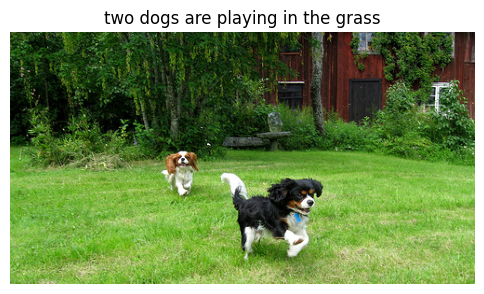

In [15]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(6,6))
plt.imshow(load_img(test_img_path))
plt.axis("off")
plt.title(caption)
plt.show()

## Caption Preprocessing

Image captions are cleaned, normalized, and stored in a dictionary format. Start and end tokens are added to each caption for sequence generation during training and inference.

In [16]:
def clean_text(s):
    s = s.strip().lower()
    s = s.translate(str.maketrans('', '', string.punctuation))
    s = " ".join([w for w in s.split() if len(w) > 0])
    return s

captions = {}
with open(captions_path, 'r') as f:
    next(f)  # skip header if present
    for line in f:
        img, cap = line.split(',', 1)
        img = img.strip()
        cap = clean_text(cap)
        full = "startseq " + cap + " endseq"
        captions.setdefault(img, []).append(full)

print("Loaded captions for images:", len(captions))

Loaded captions for images: 8091


## Evaluation using BLEU Score

The generated captions are evaluated against ground-truth human captions using BLEU (Bilingual Evaluation Understudy) metrics.

BLEU-1 evaluates unigram overlap while BLEU-4 evaluates longer phrase-level matching.

In [17]:
#================= BLEU SCORE =================
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

def compute_bleu(reference_captions, predicted_caption):
    """
    reference_captions: list of ground truth captions (list of strings)
    predicted_caption: single predicted caption (string)
    """
    # tokenize
    references = [ref.split() for ref in reference_captions]
    candidate = predicted_caption.split()

    # BLEU-1, BLEU-2, BLEU-3, BLEU-4
    bleu1 = sentence_bleu(references, candidate, weights=(1, 0, 0, 0), smoothing_function=smooth)
    bleu2 = sentence_bleu(references, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
    bleu3 = sentence_bleu(references, candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
    bleu4 = sentence_bleu(references, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)

    return bleu1, bleu2, bleu3, bleu4

## Qualitative Evaluation on Random Test Images

To evaluate the model qualitatively, random images from the Flickr8k dataset are selected. For each image:

- A caption is generated by the CNN-LSTM model.
- Ground-truth human captions are retrieved.
- BLEU scores are computed.
- The image and generated caption are displayed together.

This provides an intuitive understanding of the model's performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


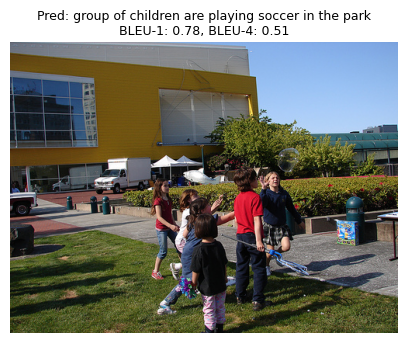

Actual captions:
- a group of children are playing with bubbles outdoors
- children play outside of a building trying to catch large bubbles
- group of kids outside a building reaching for a bubble
- the kids in front of the building are playing with a bubble
- with a yellow building in the background several children are looking in the air
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


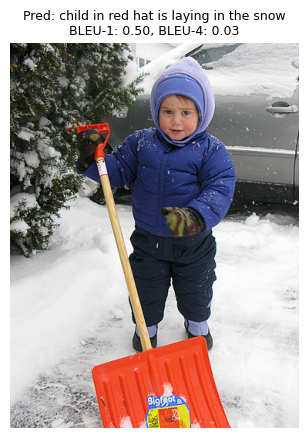

Actual captions:
- a little girl is shoveling snow
- a small child dressed all in blue for winter stands holding a red snowshovel with a snow covered mini van behind him
- a small child is shoveling snow with an orange shovel
- a toddler shovels a snowy driveway with a bright orange shovel
- a young child shovels snow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


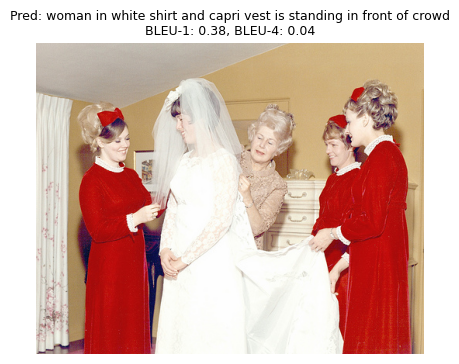

Actual captions:
- a bride getting ready with her bridesmaids wearing red
- bride wearing her wedding dress receives help by her bridesmaids wearing red dresses
- family preparing for the wedding
- the woman getting married has a beautiful gown on while her bride s maids are wearing red dresses
- three bridesmaids in red and an older woman in beige are adjusting the bride s white dress


In [18]:
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

# pick some Flickr8k images (showcase only 3 examples)
sample_images = random.sample(list(captions.keys()), 3)

for img_name in sample_images:
    img_path = os.path.join(images_path, img_name)

    # feature extraction
    feat = extract_feature(img_path)

    # predicted caption
    predicted = generate_caption(model_fixed, feat, tokenizer, max_len)

    # ground truth captions (remove startseq/endseq)
    actual = [
        cap.replace("startseq", "").replace("endseq", "").strip()
        for cap in captions[img_name]
    ]

    # compute BLEU
    bleu1, bleu2, bleu3, bleu4 = compute_bleu(actual, predicted)

    # display image
    plt.figure(figsize=(5, 5))
    plt.imshow(load_img(img_path))
    plt.axis("off")

    # show prediction + scores
    plt.title(
        f"Pred: {predicted}\nBLEU-1: {bleu1:.2f}, BLEU-4: {bleu4:.2f}",
        fontsize=9
    )

    plt.show()

    # print actual captions
    print("Actual captions:")
    for cap in actual:
        print("-", cap)

    print("=" * 80)

## Observations

The model successfully identifies major visual objects such as people, animals, boats, and water bodies. Generated captions are generally meaningful and grammatically coherent.

### Strengths

- Correct identification of primary objects.
- Good understanding of scene context.
- Ability to generate natural language descriptions.

### Limitations

- Occasional errors in object counts.
- Reduced performance on complex scenes.
- Lower BLEU-4 scores due to differences from human-written captions.

## Conclusion

This project demonstrates an end-to-end image captioning system using a CNN-LSTM architecture. InceptionV3 is used for visual feature extraction, while an LSTM-based decoder generates natural language descriptions.

The model successfully produces meaningful captions for unseen images and is evaluated using BLEU metrics against human-written captions.

## Future Improvements

- Replace LSTM with Transformer-based decoders.
- Train on larger datasets such as MS COCO.
- Incorporate attention mechanisms.
- Deploy as a web application using Flask or Streamlit.
- Improve caption quality using beam search decoding.

## Technologies Used

- Python
- TensorFlow / Keras
- InceptionV3
- LSTM
- NumPy
- Matplotlib
- NLTK
- Kaggle Notebooks